
<style>
:root { --ink:#18323f; --teal:#147d7e; --sand:#f3ead7; --rust:#c75532; --mist:#eef5f3; }
.jp-Notebook { max-width: 1180px; margin: auto; }
h1, h2, h3 { color: var(--ink); font-family: Georgia, serif; }
h1 { border-bottom: 4px solid var(--teal); padding-bottom: .25em; }
h2 { border-left: 7px solid var(--rust); padding-left: .55em; margin-top: 1.4em; }
table { font-size: 95%; }
.hero { background: linear-gradient(120deg,#173743,#147d7e); color:white; padding:28px 34px;
        border-radius:16px; margin:8px 0 22px 0; }
.hero h1 { color:white; border:0; margin:0 0 8px 0; }
.hero p { font-size:1.08rem; margin:.25rem 0; }
.callout { background:var(--mist); border-left:6px solid var(--teal); padding:14px 18px;
           border-radius:7px; margin:14px 0; }
.warning { background:#fff1e8; border-left:6px solid var(--rust); padding:14px 18px;
           border-radius:7px; margin:14px 0; }
.metric { display:inline-block; min-width:170px; background:var(--sand); padding:12px 15px;
          border-radius:10px; margin:4px; vertical-align:top; }
.metric b { display:block; font-size:1.35rem; color:var(--teal); }
.small { color:#52646d; font-size:.9rem; }
</style>



<div class="hero">
<h1>Constraint-Aware Simplex Decomposition for Robust Portfolio Reinforcement Learning</h1>
<p><b>Full project evaluation:</b> motivation, literature, problem, method, experiments, evidence, and conclusions</p>
<p>Housen Zhu | MEng Project Review | Updated from the V2.6 evidence base</p>
</div>

> **Central thesis.** Portfolio constraints have two different meanings and should not be solved by one mechanism alone. Allocation feasibility is enforced structurally through Simplex Decomposition, while path-dependent risk is controlled adaptively through reward-constrained policy optimization.


In [ ]:

from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from PIL import Image as PILImage
from IPython.display import display, Markdown

ROOT = Path.cwd()
if not (ROOT / "evaluation").exists():
    ROOT = ROOT.parent

TEST_DIR = ROOT / "evaluation" / "section9_simplex_v2.6_test_policy_comparison"
VAL_DIR = ROOT / "evaluation" / "section9_simplex_v2.6_policy_comparison"
test_summary = json.loads((TEST_DIR / "section9_comparison_summary.json").read_text())
val_summary = json.loads((VAL_DIR / "section9_comparison_summary.json").read_text())

def show_artifact(path, width=15):
    img = PILImage.open(path)
    ratio = img.height / img.width
    plt.figure(figsize=(width, width * ratio))
    plt.imshow(img)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

def policy_frame(summary):
    rows = []
    for name, m in summary["policies"].items():
        rows.append({
            "Policy": name,
            "Relative wealth": m["mean_relative_wealth_vs_constrained_neutral"],
            "Win rate": m.get("win_rate_vs_constrained_neutral", np.nan),
            "Max drawdown": m["mean_max_drawdown"],
            "Turnover": m["mean_average_turnover"],
            "Constraint-feasible branches": m["constraint_feasible_branch_rate"],
            "Allocation violation": m["mean_allocation_constraint_raw_cost"],
        })
    return pd.DataFrame(rows).set_index("Policy")

test_df = policy_frame(test_summary)
val_df = policy_frame(val_summary)


: 


## 1. Executive Summary

<div class="metric"><b>8 + 1</b>risky assets + cash</div>
<div class="metric"><b>8 / 10 / 20</b>train markets / validation branches / test branches</div>
<div class="metric"><b>+8.06%</b>best mean test wealth gain vs constrained-neutral baseline</div>
<div class="metric"><b>90%</b>test-branch win rate of RCPO Dirichlet V2.6</div>

### What has been demonstrated

- **Hard allocation constraints are satisfied by construction** under the CAOSD/Simplex policy family.
- The project evolved from a single-path PPO/RCPO prototype into a **multi-market, branch-validated research environment**.
- After fixing branch-credit gradients and rescaling the risk cost, **RCPO Dirichlet V2.6 produced the strongest current out-of-sample result**.
- A soft RCPO allocation penalty can improve return, but **does not guarantee allocation feasibility**.

<div class="warning"><b>What is not yet demonstrated:</b> reliable drawdown feasibility across future branches, multi-seed statistical significance, and transfer from the synthetic market to historical/live market data.</div>



## 2. Introduction and Motivation

Portfolio management is a sequential decision problem. At every trading step, an agent observes recent market behaviour and current holdings, chooses a new allocation, pays transaction costs, and receives the resulting portfolio return.

Return maximization alone is insufficient:

1. A policy may leave the **legally or economically feasible allocation region**.
2. A feasible policy may still create unacceptable **path-dependent losses**, such as drawdown.
3. A policy may learn one market path but fail on future continuations.
4. Financial observations and rewards can be imperfect because of prices, slippage, execution delay, and uncertain costs.

This project therefore studies a layered solution:

$$\text{Market state} \rightarrow \text{constrained action architecture} \rightarrow \text{portfolio return and risk control}.$$



## 3. Background Review

### 3.1 PPO as the optimization backbone

Proximal Policy Optimization updates the actor with a clipped likelihood-ratio objective. Clipping limits how far a policy may move on one minibatch and makes continuous-control training practical.

$$L^{\text{PPO}}(\theta)=\mathbb{E}\left[\min\left(r_t(\theta)A_t,\operatorname{clip}(r_t,1-\epsilon,1+\epsilon)A_t\right)\right].$$

### 3.2 RCPO as adaptive risk control

Reward-Constrained Policy Optimization augments the return advantage with a cost advantage:

$$A_t^{\text{combined}}=A_t^{R}-\lambda A_t^{C},$$

where the multiplier $\lambda$ rises when observed cost exceeds its tolerance and relaxes when the policy is within budget. Unlike a fixed reward weight, the pressure adapts during training.

### 3.3 CAOSD / Simplex Decomposition

Winkel et al. decompose a two-constraint portfolio simplex into four smaller branch simplexes over $V_1\cap V_2$, $V_1$, $V_2$, and the full universe. Branch portfolios are recombined with feasible masses $z_1,\ldots,z_4$. This converts allocation feasibility from a learned preference into an architectural property.

### 3.4 Robust reward feedback

The Distributional Reward Critic (DRC/GDRC) literature motivates a later project phase: infer a cleaner training signal when observed state/reward feedback is perturbed. In the current V2.6 comparison this module is deliberately disabled, so the constraint architecture can be evaluated first.

**Key literature:** [PPO](https://arxiv.org/abs/1707.06347), [RCPO](https://openreview.net/forum?id=SkfrvsA9FX), [CAOSD](https://arxiv.org/abs/2404.10683), [DRC/GDRC](https://arxiv.org/abs/2401.05710), and the [2024 safe-RL constraint-formulation survey](https://www.ijcai.org/proceedings/2024/913).



## 4. Problem Statement and Research Questions

### Formal objective

Learn a policy that maximizes net portfolio growth while respecting:

- **Hard allocation constraints:** minimum exposure to two overlapping asset groups.
- **Adaptive path-risk constraint:** drawdown relative to a constrained-neutral benchmark.
- **Generalization requirement:** performance on unseen future market branches, not only the training paths.

### Research questions

| ID | Question | Evidence used here |
|---|---|---|
| RQ1 | Can Simplex Decomposition guarantee allocation feasibility without destroying learning? | Allocation violation and return across Gaussian/Dirichlet PPO/RCPO |
| RQ2 | Does adaptive RCPO risk control improve the return-risk trade-off over pure PPO? | Relative wealth, drawdown cost, feasible-branch rate, lambda diagnostics |
| RQ3 | Is a soft allocation penalty a substitute for structural feasibility? | Soft RCPO vs hard-simplex policies |
| RQ4 | Which policy distribution is more effective: Gaussian logits or Dirichlet branch weights? | V2.6 validation and 20-branch test comparisons |
| RQ5 | Does performance transfer beyond selected validation branches? | Validation-to-test gap and branch dispersion |



## 5. Environment and Synthetic Market

### Portfolio and interaction loop

- **Assets:** cash plus eight risky assets in the V2.5/V2.6 environment.
- **Observation:** trailing returns, rolling means/volatility, current allocation, turnover, and diagnostics. The latent regime is hidden.
- **Action:** branch logits or branch weights, mapped by CAOSD into a long-only portfolio that sums to one.
- **Reward:** clean net portfolio log return after transaction cost.
- **Episode:** 252 trading steps; every episode begins from the constrained-neutral CAOSD allocation.
- **Training diversity:** eight deterministic but distinct train markets; episodes sample from the pool.
- **Future evaluation:** ten validation branches and twenty test branches continuing from the anchor training endpoint.

### Learnable synthetic structure

The market contains persistent low-/high-volatility regimes, regime-dependent asset winners, mild momentum, and higher cross-asset correlation in the high-volatility regime. The design creates a learnable allocation signal without exposing the regime label.

### Allocation constraints used in Experiment 2

$$V_1=\{1,4,6\},\quad \sum_{i\in V_1}w_i\geq0.50$$

$$V_2=\{2,4,7\},\quad \sum_{i\in V_2}w_i\geq0.40$$

These groups avoid the earlier trivial case in which the most profitable asset also solved both constraints. Because $0.50+0.40\leq1$, mandatory overlap mass is zero; branch 1 is skipped when its CAOSD mass is inactive.


## 6. Method: End-to-End Pipeline

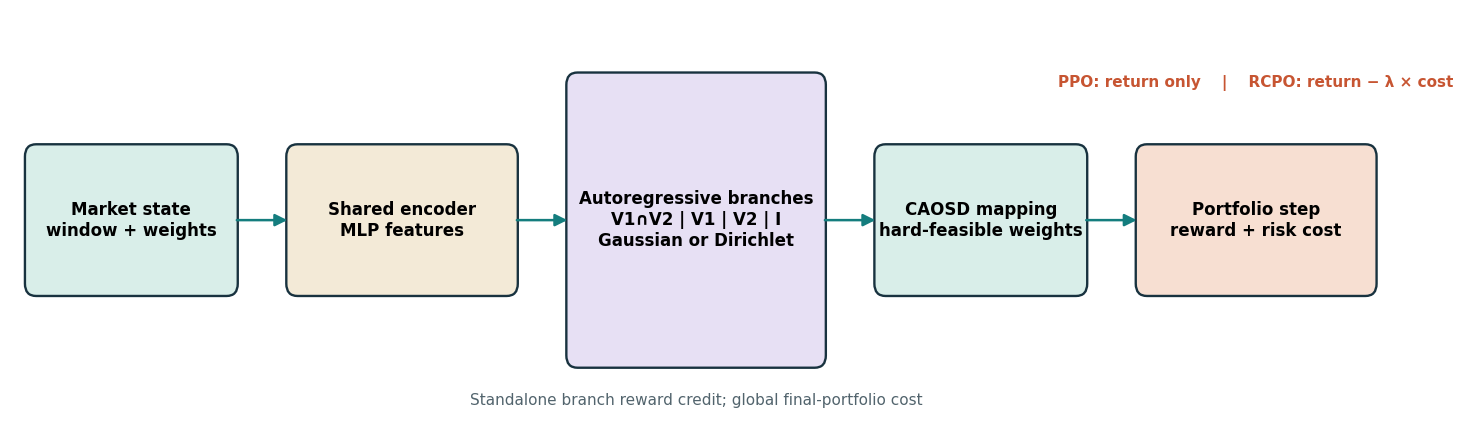

In [2]:

from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
fig, ax = plt.subplots(figsize=(15, 4.4))
ax.set_xlim(0, 15); ax.set_ylim(0, 4); ax.axis("off")
boxes = [
    (0.2, 1.25, 2.2, 1.4, "Market state\nwindow + weights", "#d9eee9"),
    (3.0, 1.25, 2.4, 1.4, "Shared encoder\nMLP features", "#f3ead7"),
    (6.0, 0.55, 2.7, 2.8, "Autoregressive branches\nV1∩V2 | V1 | V2 | I\nGaussian or Dirichlet", "#e7e0f4"),
    (9.3, 1.25, 2.2, 1.4, "CAOSD mapping\nhard-feasible weights", "#d9eee9"),
    (12.1, 1.25, 2.5, 1.4, "Portfolio step\nreward + risk cost", "#f7dfd2"),
]
for x,y,w,h,label,color in boxes:
    ax.add_patch(FancyBboxPatch((x,y),w,h,boxstyle="round,pad=.04,rounding_size=.12",
                                fc=color,ec="#18323f",lw=1.7))
    ax.text(x+w/2,y+h/2,label,ha="center",va="center",fontsize=12,weight="bold")
for x1,x2 in [(2.4,3.0),(5.4,6.0),(8.7,9.3),(11.5,12.1)]:
    ax.add_patch(FancyArrowPatch((x1,1.95),(x2,1.95),arrowstyle="-|>",mutation_scale=18,
                                 lw=1.8,color="#147d7e"))
ax.text(7.35,0.15,"Standalone branch reward credit; global final-portfolio cost",ha="center",
        color="#52646d",fontsize=11)
ax.text(13.35,3.25,"PPO: return only    |    RCPO: return − λ × cost",ha="center",
        color="#c75532",fontsize=11,weight="bold")
plt.tight_layout(); plt.show()



### 6.1 CAOSD feasibility mapping

Each branch produces a probability vector $y_i$ over its asset subset. The final portfolio is

$$w=z_1y_1+z_2y_2+z_3y_3+z_4y_4,$$

with $z_i\ge0$ and $\sum_i z_i=1$. The CAOSD construction chooses these masses so both minimum-weight constraints hold. Therefore, allocation violations are approximately zero before PPO or RCPO learns anything.

### 6.2 Two policy distributions

| Policy | Branch output | Autoregressive conditioning | Main trade-off |
|---|---|---|---|
| Gaussian | Real-valued logits, then branch softmax | Previous branch softmax allocations | Stable parameterization but redundant/logit-sensitive geometry |
| Dirichlet | Positive simplex weights directly | Previous sampled branch weights | Matches simplex geometry, but can become concentrated or high-turnover |

Both share one encoder. In standalone branch-credit mode, each active branch obtains its own reward advantage, while the final portfolio supplies one global constraint cost and one global lambda.



## 7. RCPO Risk Constraint in V2.6

The V2.6 risk signal uses **relative current drawdown**, not a fixed absolute maximum-drawdown budget.

For the agent and constrained-neutral benchmark:

$$D_t=\frac{P_t^{\max}-P_t}{P_t^{\max}},\qquad D_t^{B}=\frac{(P_t^{B})^{\max}-P_t^B}{(P_t^{B})^{\max}}.$$

The online budget and violation are

$$b_t=\max(0.05,\;0.90D_t^B),$$

$$v_t=\max(0,\;D_t-b_t),\qquad c_t=\frac{v_t^2}{0.10}.$$

The cost tolerance is scaled to the current budget:

$$\alpha_t=\frac{(0.05b_t)^2}{0.10}.$$

The multiplier is updated **once per rollout**, not once per PPO epoch:

$$\lambda\leftarrow\max\left(0,\lambda+\eta_\lambda(\bar c-\bar\alpha)\right).$$

<div class="callout"><b>Interpretation:</b> allocation constraints are hard and always active; drawdown is soft and adaptive. The agent is asked to remain about 10% safer than the online constrained-neutral benchmark, with a 5% floor preventing a near-zero budget at the start of an episode.</div>



## 8. Training and Evaluation Design

| Component | Current V2.6 setting | Why it matters |
|---|---:|---|
| Train-market pool | 8 independent markets | Reduces memorization of one synthetic path |
| Episode length | 252 steps | One trading-year horizon |
| Rollout | 2,048 steps | Covers roughly eight episodes before each update |
| Validation | 10 future branches | Checkpoint selection uses branch mean, not one continuation |
| Test | 20 unseen branches | Final evidence only; clean rewards |
| Checkpoints | best return + best feasible-rate | Separates performance selection from safety selection |
| Baseline | constrained-neutral CAOSD | Same hard feasible set as simplex policies |

### Fairness rule

The displayed return is relative wealth, not a subtraction of returns:

$$\text{relative wealth}=\frac{W_T^{\text{policy}}}{W_T^{\text{baseline}}}-1.$$

This comparison is branch-specific and remains meaningful even when the baseline return is negative.



## 9. Development Path: What Changed and Why

| Phase | Design | Main observation | Consequence |
|---|---|---|---|
| Early PPO/RCPO | One market path, softmax actor | Strong train fit; unreliable future performance | Multi-market training and branch validation |
| Reward robustness | Gaussian noisy reward + DRC/GDRC | Correction could be too coarse or biased | Stabilized fine bins and deferred as secondary scope |
| Simplex V1 | One flat joint output | Weak learning signal | Separate branch structure |
| Simplex V2 | Parallel Gaussian branches | Joint credit assignment remained slow/unstable | Autoregressive branches |
| V2.1-V2.5 | Gaussian/Dirichlet + standalone credit | Lambda/cost scale and KL behaviour exposed | Cost rescaling, dynamic alpha, KL pre-step checks |
| V2.6 | Relative current drawdown + repaired branch gradients | Better Dirichlet RCPO transfer; hard feasibility retained | Current evidence base and counterfactual-credit next step |

**Important engineering finding.** A standalone-branch ratio had accidentally been evaluated without gradients. That made part of the apparent V2.6 evidence invalid. The implementation was repaired and the current V2.6 runs were regenerated after the fix.


## 10. Experiment Results: 20 Future Test Markets

In [3]:

display_df = test_df.copy()
for c in ["Relative wealth", "Win rate", "Max drawdown", "Turnover", "Constraint-feasible branches", "Allocation violation"]:
    display_df[c] = display_df[c].map(lambda x: f"{x:+.2%}" if c == "Relative wealth" else f"{x:.2%}")
display(display_df)


,Relative wealth,Win rate,Max drawdown,Turnover,Constraint-feasible branches,Allocation violation
Policy,,,,,,
PPO Gaussian v2.6,+4.83%,75.00%,17.99%,9.16%,100.00%,0.00%
PPO Dirichlet v2.6,+5.58%,70.00%,17.41%,15.47%,100.00%,0.00%
RCPO Gaussian v2.6,+4.61%,70.00%,19.14%,1.91%,15.00%,0.00%
RCPO Dirichlet v2.6,+8.06%,90.00%,16.73%,14.27%,40.00%,0.00%
RCPO Allocation Penalty,+5.86%,80.00%,16.99%,8.65%,0.00%,1.55%
RCPO Allocation + Drawdown,+5.46%,75.00%,17.43%,6.82%,0.00%,2.06%
Constrained-neutral baseline,+0.00%,nan%,16.70%,0.00%,100.00%,0.00%



### Main empirical findings

1. **RCPO Dirichlet V2.6 is the strongest current return result:** +8.06% mean relative wealth and a 90% branch win rate.
2. **Hard simplex feasibility works:** all four simplex policies report zero allocation-constraint violation.
3. **Soft allocation RCPO is not a hard-constraint solver:** both soft variants have 0% active-constraint feasible branches.
4. **Risk control is still incomplete:** RCPO Gaussian and Dirichlet satisfy their active drawdown criterion on only 15% and 40% of test branches.
5. **The best-return model is not necessarily the safest model:** the constrained-neutral baseline has lower drawdown than most learned policies.


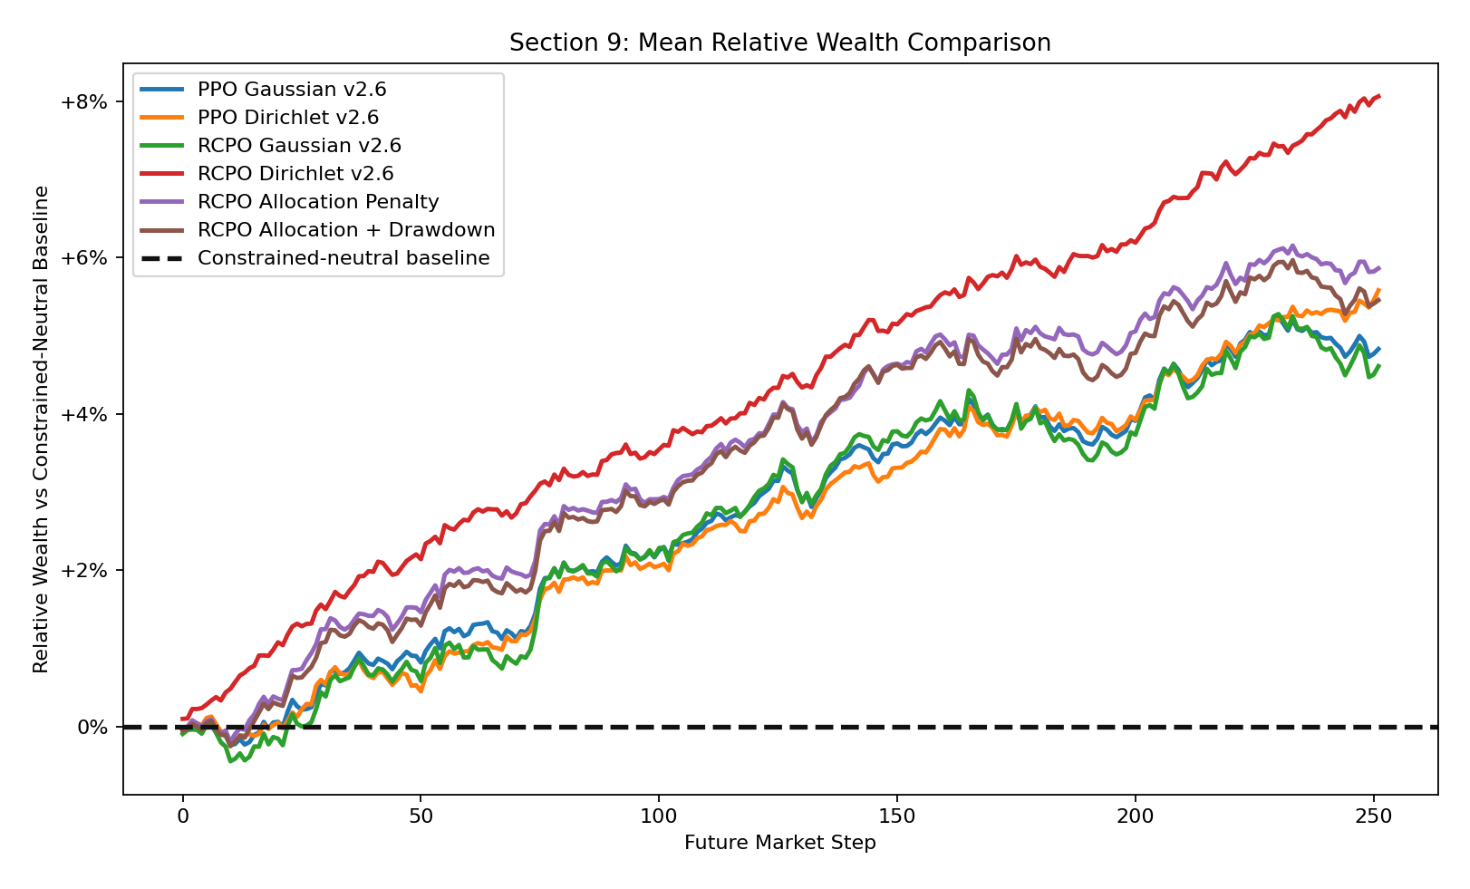

In [4]:
show_artifact(TEST_DIR / 'section9_cumulative_return_means_only.png')


**Reading the plot.** The horizontal zero line is the constrained-neutral baseline. Every method is evaluated on the same twenty clean future branches; the curve is the mean branch-wise wealth ratio. RCPO Dirichlet separates after roughly 30-40 steps and retains the lead to the end.


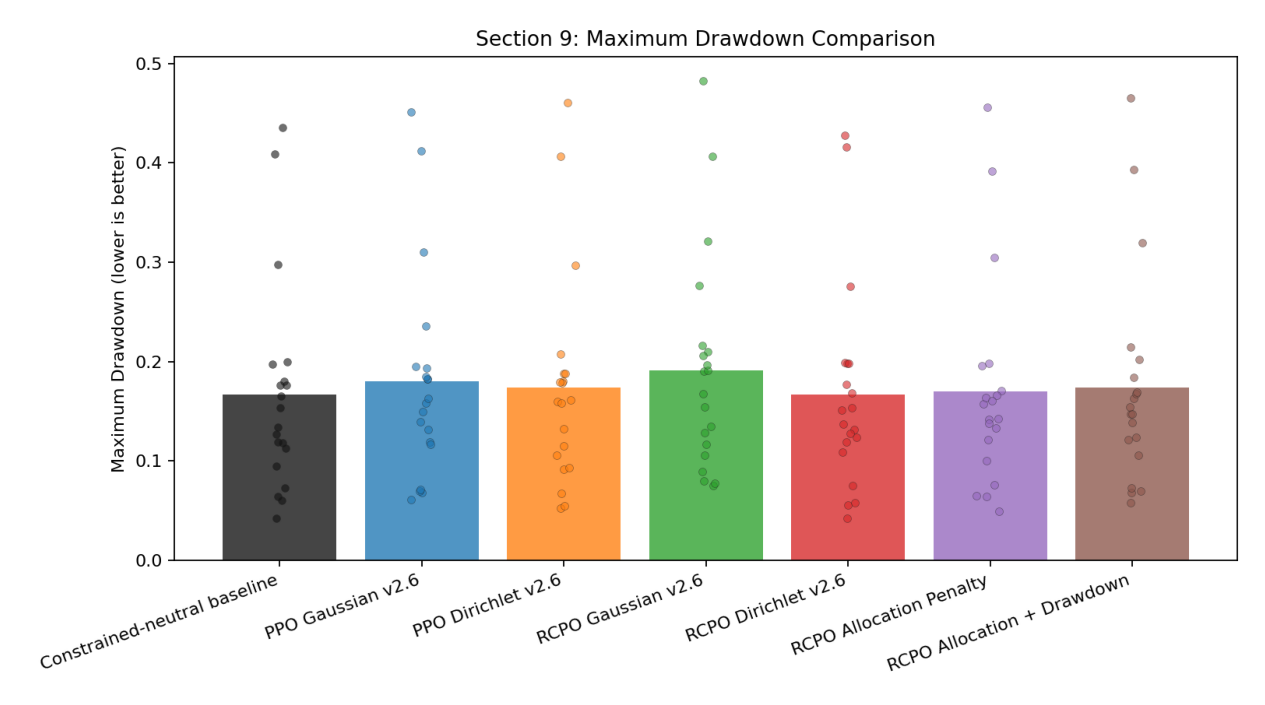

In [5]:
show_artifact(TEST_DIR / 'section9_max_drawdown_comparison.png', 13)

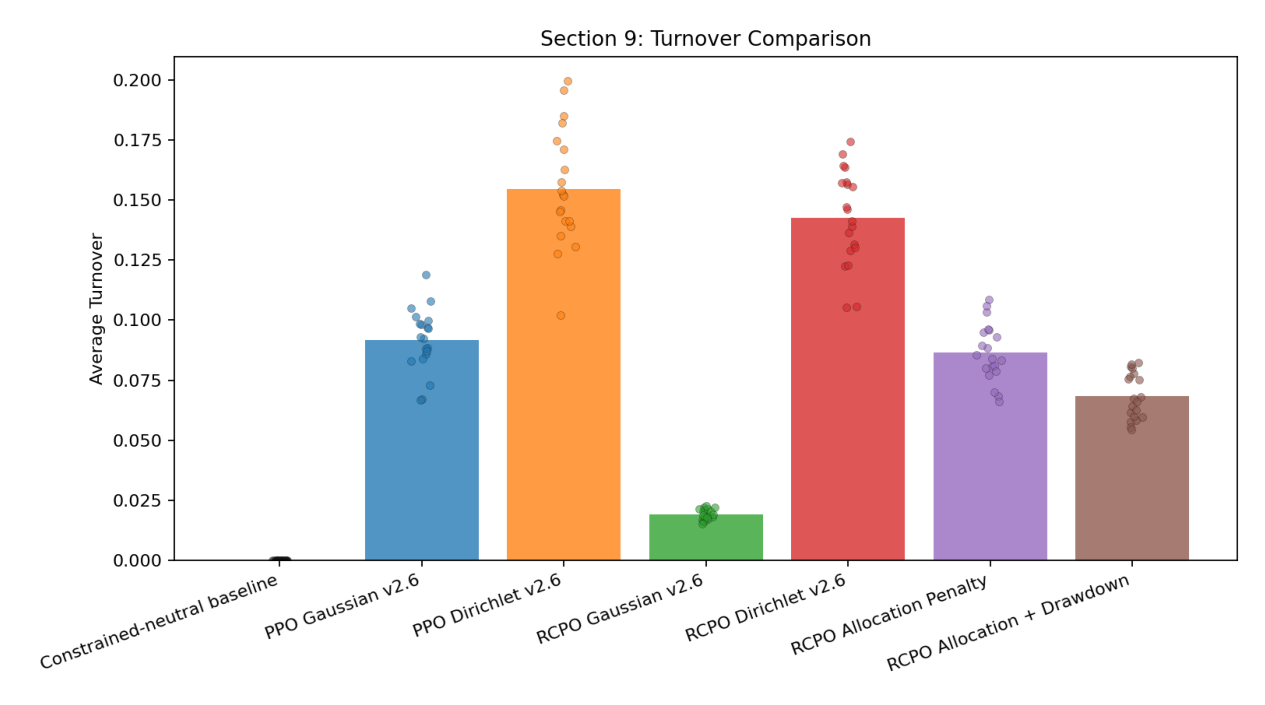

In [6]:
show_artifact(TEST_DIR / 'section9_turnover_comparison.png', 13)

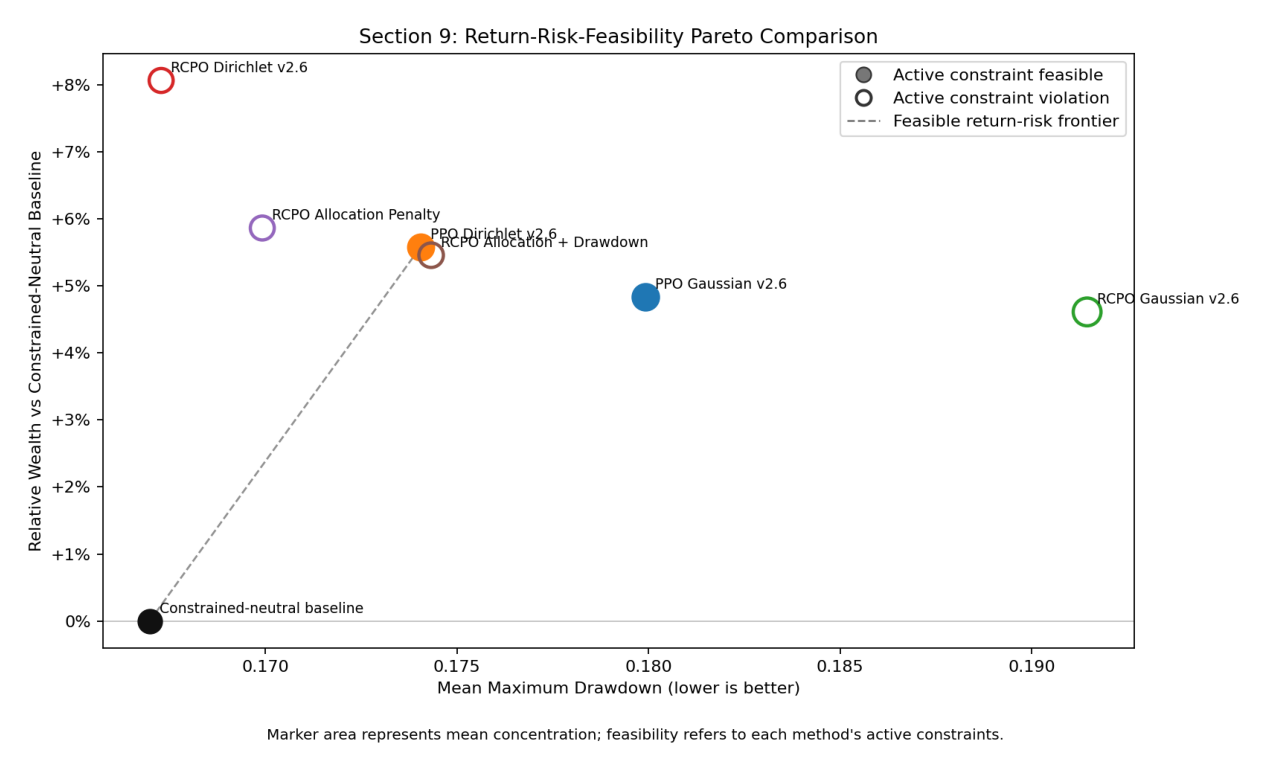

In [7]:
show_artifact(TEST_DIR / 'section9_return_risk_feasibility_pareto.png', 13)


## 11. Validation-to-Test Generalization

Checkpoint selection used validation branches only. The table below measures how much relative wealth declined on the independent test set.


In [8]:

names = [n for n in test_df.index if n != "Constrained-neutral baseline"]
gap = pd.DataFrame({
    "Validation relative wealth": [val_df.loc[n, "Relative wealth"] for n in names],
    "Test relative wealth": [test_df.loc[n, "Relative wealth"] for n in names],
}, index=names)
gap["Test minus validation"] = gap["Test relative wealth"] - gap["Validation relative wealth"]
display(gap.style.format("{:+.2%}"))


,Validation relative wealth,Test relative wealth,Test minus validation
PPO Gaussian v2.6,+9.88%,+4.83%,-5.05%
PPO Dirichlet v2.6,+9.37%,+5.58%,-3.79%
RCPO Gaussian v2.6,+11.20%,+4.61%,-6.59%
RCPO Dirichlet v2.6,+8.90%,+8.06%,-0.84%
RCPO Allocation Penalty,+9.28%,+5.86%,-3.42%
RCPO Allocation + Drawdown,+9.68%,+5.46%,-4.22%



The gap remains material for most methods. RCPO Dirichlet is the exception: its validation-to-test decline is under one percentage point. This is encouraging, but one seed is not enough to establish statistical reliability.


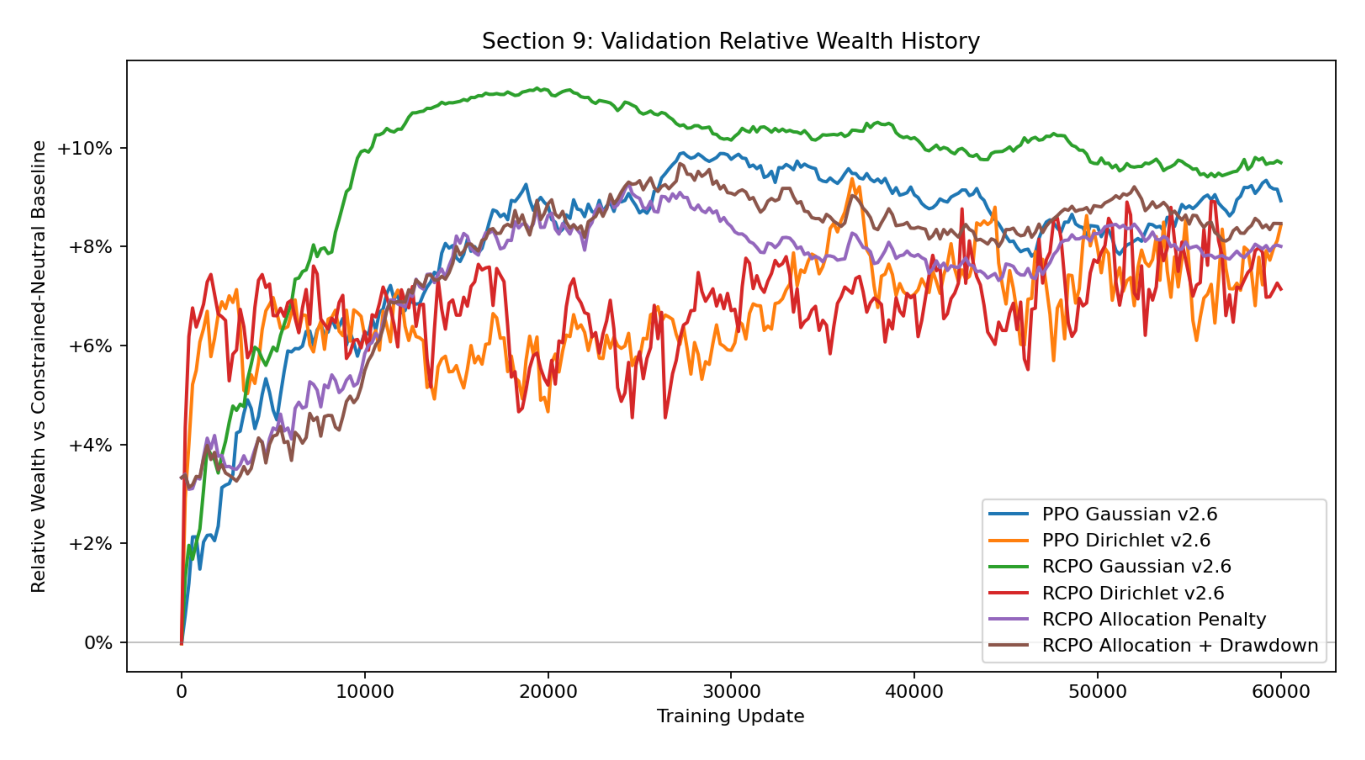

In [9]:
show_artifact(TEST_DIR / 'section9_validation_score_history.png', 14)


## 12. Project Contributions

### Methodological

- A practical CAOSD implementation with configurable Gaussian-logit and Dirichlet branch policies.
- A hybrid interpretation of constraints: **structural allocation feasibility + adaptive path-risk control**.
- Standalone branch reward credit with a global final-portfolio cost signal.
- Relative-current-drawdown budgeting against an online constrained-neutral benchmark.

### Experimental

- Deterministic multi-market training and multi-branch checkpoint selection.
- Clean future-branch comparison with relative wealth, drawdown, turnover, concentration, feasibility, and branch dispersion.
- Direct comparison of hard Simplex Decomposition against soft RCPO allocation penalties.

### Engineering

- Checkpoint compatibility checks across action mode, policy family, branch structure, and constraint semantics.
- Reproducible evaluation artifacts and explicit best-return / best-feasible checkpoint semantics.



## 13. Current Conclusion

<div class="callout"><b>Current answer to the project question:</b> Simplex Decomposition is effective for hard allocation feasibility, while RCPO can improve the policy's return-risk behaviour but does not yet provide reliable future-branch drawdown feasibility. The strongest current configuration is autoregressive Dirichlet + RCPO, but the claim remains provisional until multi-seed and historical-market validation are completed.</div>

The most important scientific result is not simply the +8.06% test improvement. It is the separation of three ideas that had previously been mixed together:

1. **Feasibility** should be guaranteed by the action architecture when possible.
2. **Risk preference** can be learned through a cost and adaptive multiplier.
3. **Generalization** must be measured across independent future branches and seeds.



## 14. Evidence and Reproducibility Map

This notebook was assembled from the project artifacts below:

- `HousenZhu_MEng_Project_Syllabus/main.tex` - approved project scope and milestones.
- `reports/simplex_v25_v26_progress_meeting_20260805.md` - V2.5/V2.6 design narrative and comparisons.
- `reports/v2.6/` - training-core redesign, diagnostics, and counterfactual phase proposal.
- `evaluation/section9_simplex_v2.6_policy_comparison/` - shared validation-branch evidence.
- `evaluation/section9_simplex_v2.6_test_policy_comparison/` - shared 20-market test evidence used in the main results.
- `runs/simplex_v2.6_*` - checkpoint snapshots, metrics logs, and per-run artifacts.
- `slides/simplex_v25_v26_progress_20260805/` - prior presentation materials.

All V2.6 return plots use clean evaluation returns and the constrained-neutral CAOSD baseline.



## 15. Selected References

1. Winkel et al., **Simplex Decomposition for Portfolio Allocation Constraints in Reinforcement Learning**, ECAI / [arXiv:2404.10683](https://arxiv.org/abs/2404.10683).
2. Tessler, Mankowitz, and Mannor, **Reward Constrained Policy Optimization**, ICLR 2019, [OpenReview](https://openreview.net/forum?id=SkfrvsA9FX).
3. Schulman et al., **Proximal Policy Optimization Algorithms**, 2017, [arXiv:1707.06347](https://arxiv.org/abs/1707.06347).
4. Wachi, Shen, and Sui, **A Survey of Constraint Formulations in Safe Reinforcement Learning**, IJCAI 2024, [DOI / proceedings](https://www.ijcai.org/proceedings/2024/913).
5. Chen, Zhu, and Perrault, **The Distributional Reward Critic Framework for Reinforcement Learning Under Perturbed Rewards**, 2024, [arXiv:2401.05710](https://arxiv.org/abs/2401.05710).
6. Gao et al., **Exterior Penalty Policy Optimization with Penalty Metric Network under Constraints**, IJCAI 2024, [proceedings](https://www.ijcai.org/proceedings/2024/443).
7. Enkhsaikhan and Jo, **Augmented Lagrangian Risk-constrained Reinforcement Learning for Portfolio Optimization**, AAAI 2025 student abstract, [AAAI](https://ojs.aaai.org/index.php/AAAI/article/view/35252).
8. Choudhary et al., **Risk-Adjusted Deep Reinforcement Learning for Portfolio Optimization: A Multi-reward Approach**, 2025, [Springer](https://link.springer.com/article/10.1007/s44196-025-00875-8).
